# 06 LSTM 基线训练（从0到1）

目标：先跑通一个可复现的 LSTM 基线，并明确说明 **输入、网络结构、输出**。

## 1) 模型 I/O 与结构说明

- **输入（Input）**：形状为 `(batch_size, seq_length, num_features)` 的序列张量。
  - 本项目中 `num_features = 5`，分别是：
    1. 放电时长 `discharge_time`
    2. 最高温度 `max_temp`
    3. 环境温度 `ambient_temp_c`
    4. 放电电流 `discharge_current_a`
    5. 截止电压 `cutoff_voltage_v`
- **网络结构（Network）**：`LSTM(input_dim=5) -> 取最后时间步隐状态 -> Linear -> 1维输出`。
- **输出（Output）**：形状为 `(batch_size, 1)`，表示“下一时刻容量预测值”（后续可映射到 RUL 分析）。

In [1]:
import os
import sys
import json
import random
from datetime import datetime

import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = r"C:\\Users\\PLUTO\\Desktop\\battery-rul"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.Transformer.data import (
    load_battery_raw_parameters,
    default_condition_map,
    build_protocol_splits,
    prepare_condition_aware_dataloaders,
)
from src.Transformer.train import train_model, predict, compute_regression_metrics
from src.LSTM.model import ClassicLSTMRegressor, default_lstm_kwargs

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [2]:
# 加载全部可用电池（按 condition_map 过滤）
PROCESSED_ROOT = os.path.join(PROJECT_ROOT, "data\\processed")
condition_map = default_condition_map()
target_ids = set(condition_map.keys())

battery_dict = {}
for group_name in sorted(os.listdir(PROCESSED_ROOT)):
    group_path = os.path.join(PROCESSED_ROOT, group_name)
    if not os.path.isdir(group_path):
        continue

    pkl_files = [f for f in os.listdir(group_path) if f.endswith(".pkl")]
    group_ids = [os.path.splitext(f)[0] for f in pkl_files]
    group_ids = [bid for bid in group_ids if bid in target_ids]
    if not group_ids:
        continue

    group_data = load_battery_raw_parameters(group_path, group_ids)
    battery_dict.update(group_data)

available_ids = sorted([bid for bid in battery_dict if bid in condition_map])
print("总电池数:", len(available_ids))
print("前10个ID:", available_ids[:10])

总电池数: 34
前10个ID: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030']


## 2) 先用一个 split 开始训练（same_condition 冒烟）

说明：先跑通流程，后续再改为全量 split。

In [3]:
protocols = build_protocol_splits(available_ids, condition_map)
print("same_condition splits:", len(protocols["same_condition"]))

split = protocols["same_condition"][0]
train_ids = split["train_ids"]
test_id = split["test_ids"][0]

print("当前split组别:", split.get("group", "N/A"))
print("训练电池数:", len(train_ids))
print("测试电池:", test_id)

same_condition splits: 34
当前split组别: T24_I2
训练电池数: 4
测试电池: B0005


In [4]:
SEQ_LENGTH = 10
BATCH_SIZE = 32

train_loader, test_loader, scaler_y, test_actual_capacity = prepare_condition_aware_dataloaders(
    battery_dict=battery_dict,
    train_ids=train_ids,
    test_id=test_id,
    condition_map=condition_map,
    seq_length=SEQ_LENGTH,
    batch_size=BATCH_SIZE,
)

x_batch, y_batch = next(iter(train_loader))
print("输入张量 x 形状:", tuple(x_batch.shape), "= (batch, seq_len, features)")
print("标签张量 y 形状:", tuple(y_batch.shape), "= (batch, 1)")
print("特征维度 num_features:", x_batch.shape[-1])

输入张量 x 形状: (32, 10, 5) = (batch, seq_len, features)
标签张量 y 形状: (32, 1) = (batch, 1)
特征维度 num_features: 5


In [5]:
# 定义 LSTM 网络
model_kwargs = default_lstm_kwargs()
model = ClassicLSTMRegressor(**model_kwargs)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("可训练参数量:", num_params)

# 前向维度检查
with torch.no_grad():
    y_hat = model(x_batch.float())
print("模型输出 y_hat 形状:", tuple(y_hat.shape), "= (batch, 1)")

ClassicLSTMRegressor(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.1)
  (head): Linear(in_features=64, out_features=1, bias=True)
)
可训练参数量: 51521
模型输出 y_hat 形状: (32, 1) = (batch, 1)


e:\conda\envs\battery-rul\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\battery-rul\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32476 (\N{CJK UNIFIED IDEOGRAPH-7EDC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\battery-rul\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\battery-rul\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\battery-rul\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaV

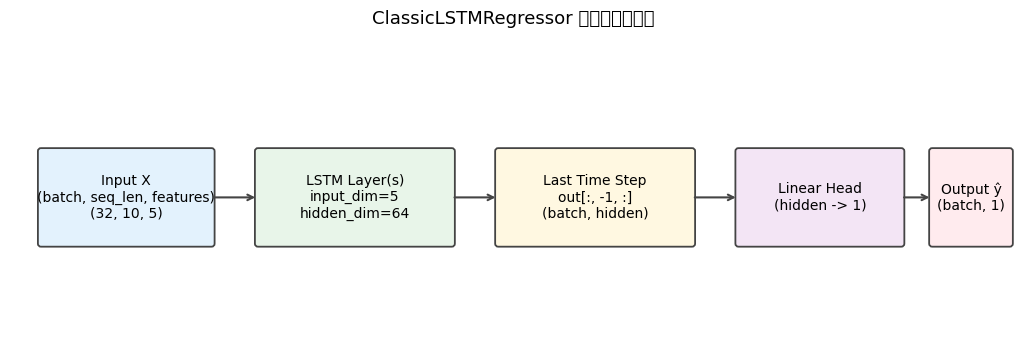

In [6]:
# 网络结构可视化（Input -> LSTM -> Last Step -> Linear -> Output）
import matplotlib.pyplot as plt
import matplotlib.patches as patches

batch_size = int(x_batch.shape[0])
seq_len = int(x_batch.shape[1])
num_features = int(x_batch.shape[2])
hidden_dim = int(model_kwargs["hidden_dim"])

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.set_xlim(0, 13)
ax.set_ylim(0, 3.8)
ax.axis("off")

boxes = [
    (0.4, 1.2, 2.2, 1.2, "Input X\n(batch, seq_len, features)\n({}, {}, {})".format(batch_size, seq_len, num_features), "#E3F2FD"),
    (3.2, 1.2, 2.5, 1.2, "LSTM Layer(s)\ninput_dim={}\nhidden_dim={}".format(num_features, hidden_dim), "#E8F5E9"),
    (6.3, 1.2, 2.5, 1.2, "Last Time Step\nout[:, -1, :]\n(batch, hidden)", "#FFF8E1"),
    (9.4, 1.2, 2.1, 1.2, "Linear Head\n(hidden -> 1)", "#F3E5F5"),
    (11.9, 1.2, 1.0, 1.2, "Output ŷ\n(batch, 1)", "#FFEBEE"),
]

for x0, y0, w, h, text, color in boxes:
    rect = patches.FancyBboxPatch(
        (x0, y0), w, h,
        boxstyle="round,pad=0.04",
        linewidth=1.3,
        edgecolor="#444444",
        facecolor=color
    )
    ax.add_patch(rect)
    ax.text(x0 + w / 2, y0 + h / 2, text, ha="center", va="center", fontsize=10)

for start_x, end_x in [(2.6, 3.2), (5.7, 6.3), (8.8, 9.4), (11.5, 11.9)]:
    ax.annotate("", xy=(end_x, 1.8), xytext=(start_x, 1.8),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="#444444"))

ax.set_title("ClassicLSTMRegressor 网络结构示意图", fontsize=13, pad=14)
plt.show()

In [7]:
# 开始训练
TRAIN_KWARGS = {"epochs": 20, "lr": 1e-3}
history = train_model(
    model=model,
    train_loader=train_loader,
    device=device,
    **TRAIN_KWARGS,
)

print("训练完成，最后5轮loss:", [round(v, 6) for v in history[-5:]])

训练完成，最后5轮loss: [0.001934, 0.001641, 0.001603, 0.001614, 0.00154]


In [8]:
# 测试评估
preds = predict(model=model, test_loader=test_loader, scaler_y=scaler_y, device=device)
y_true = test_actual_capacity[SEQ_LENGTH:SEQ_LENGTH + len(preds)]
metrics = compute_regression_metrics(y_true, preds)

print("评估结果:")
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")
print("预测点数:", len(preds))

评估结果:
RMSE: 0.065399
MAE: 0.061489
MAPE: 4.014945
预测点数: 158


In [9]:
# 最小保存规范示例：保存权重 + 配置 + 指标
SAVE_ROOT = os.path.join(PROJECT_ROOT, "results", "lstm_baseline")
os.makedirs(SAVE_ROOT, exist_ok=True)

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = os.path.join(SAVE_ROOT, f"same_condition_lstm_split0_seed{SEED}_{run_tag}.pt")
meta_path = os.path.join(SAVE_ROOT, f"same_condition_lstm_split0_seed{SEED}_{run_tag}.json")

torch.save(model.state_dict(), model_path)

meta = {
    "protocol": "same_condition",
    "model": "ClassicLSTMRegressor",
    "split_id": 0,
    "seed": SEED,
    "train_ids": train_ids,
    "test_id": test_id,
    "seq_length": SEQ_LENGTH,
    "batch_size": BATCH_SIZE,
    "train_kwargs": TRAIN_KWARGS,
    "model_kwargs": model_kwargs,
    "metrics": metrics,
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("模型已保存:", model_path)
print("元信息已保存:", meta_path)

模型已保存: C:\\Users\\PLUTO\\Desktop\\battery-rul\results\lstm_baseline\same_condition_lstm_split0_seed42_20260325_102253.pt
元信息已保存: C:\\Users\\PLUTO\\Desktop\\battery-rul\results\lstm_baseline\same_condition_lstm_split0_seed42_20260325_102253.json


## 多

1. 先按顺序运行到第11个单元，确认 LSTM 单个 split 已跑通。
2. 将第6个单元中的 `split = protocols["same_condition"][0]` 改成循环，跑完整 `same_condition`。
3. 再复用同模板切换到 `lobo` 和 `loco`，形成第四章对比结果。

## 多 split 运行

## protocol 结构详解（重点）

`build_protocol_splits(...)` 的返回值是一个字典：

- `protocols["same_condition"]`：列表，列表中每个元素是一个 split 字典。
- `protocols["lobo"]`：列表，元素同样是 split 字典。
- `protocols["loco"]`：列表，元素同样是 split 字典。

每个 split 字典的核心键：

- `train_ids`：本 split 的训练电池 ID 列表。
- `test_ids`：本 split 的测试电池 ID 列表（same_condition 和 lobo 通常长度为 1；loco 常常大于 1）。
- `group`：工况组名（例如 `T24_I4`），有些 split 可能没有这个键。

所以你在循环中要注意：

1. 每次 `split` 都必须重新构建 dataloader（不能复用旧的 `train_loader/test_loader`）。
2. 不能假设 `test_ids` 永远只有1个，尤其在 `loco` 下通常是多个。
3. `group` 要用 `split.get("group", "N/A")` 取值，避免键不存在时报错。
4. `y_true` 与 `preds` 必须来自同一个 split，不能用上一个 split 的缓存变量。

简化理解：**split 是一次完整实验单元（数据划分 + 训练 + 评估）**。

In [10]:
records = []
TRAIN_KWARGS = {"epochs": 20, "lr": 1e-3}

for split_id, split in enumerate(protocols["same_condition"]):
    train_ids = split["train_ids"]
    test_id = split["test_ids"][0]

    print("=" * 70)
    print(f"split_id: {split_id}")
    print("当前split组别:", split.get("group", "N/A"))
    print("训练电池数:", len(train_ids))
    print("测试电池:", test_id)

    try:
        train_loader, test_loader, scaler_y, test_actual_capacity = prepare_condition_aware_dataloaders(
            battery_dict=battery_dict,
            train_ids=train_ids,
            test_id=test_id,
            condition_map=condition_map,
            seq_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
        )
    except ValueError as e:
        print("跳过该split，原因:", e)
        continue

    model_kwargs = default_lstm_kwargs()
    model = ClassicLSTMRegressor(**model_kwargs)

    history = train_model(
        model=model,
        train_loader=train_loader,
        device=device,
        **TRAIN_KWARGS,
    )
    print("训练完成，最后5轮loss:", [round(v, 6) for v in history[-5:]])

    preds = predict(model=model, test_loader=test_loader, scaler_y=scaler_y, device=device)
    y_true = test_actual_capacity[SEQ_LENGTH:SEQ_LENGTH + len(preds)]
    metrics = compute_regression_metrics(y_true, preds)

    print("评估结果:")
    for k, v in metrics.items():
        print(f"{k}: {v:.6f}")
    print("预测点数:", len(preds))

    records.append(
        {
            "split_id": split_id,
            "protocol": "same_condition",
            "group": split.get("group", "N/A"),
            "test_id": test_id,
            "num_train_batteries": len(train_ids),
            "num_points": int(len(preds)),
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "MAPE": metrics["MAPE"],
        }
    )

df_same_condition = pd.DataFrame(records)
print("\n总有效split数:", len(df_same_condition))
display(df_same_condition.head())

if not df_same_condition.empty:
    summary_same = df_same_condition[["RMSE", "MAE", "MAPE"]].agg(["mean", "std"]).T
    summary_same.columns = ["mean", "std"]
    print("\n=== same_condition 全量评估汇总（LSTM）===")
    display(summary_same)

split_id: 0
当前split组别: T24_I2
训练电池数: 4
测试电池: B0005
训练完成，最后5轮loss: [0.001734, 0.001557, 0.002086, 0.001824, 0.001585]
评估结果:
RMSE: 0.108571
MAE: 0.105910
MAPE: 6.961907
预测点数: 158
split_id: 1
当前split组别: T24_I2
训练电池数: 4
测试电池: B0006
训练完成，最后5轮loss: [0.001176, 0.001188, 0.001146, 0.001232, 0.00106]
评估结果:
RMSE: 0.078491
MAE: 0.059448
MAPE: 3.705856
预测点数: 158
split_id: 2
当前split组别: T24_I2
训练电池数: 4
测试电池: B0007
训练完成，最后5轮loss: [0.001792, 0.001721, 0.001878, 0.001899, 0.001847]
评估结果:
RMSE: 0.221791
MAE: 0.220025
MAPE: 13.673763
预测点数: 158
split_id: 3
当前split组别: T24_I2
训练电池数: 4
测试电池: B0018
训练完成，最后5轮loss: [0.002257, 0.001937, 0.0018, 0.001921, 0.001547]
评估结果:
RMSE: 0.099542
MAE: 0.090496
MAPE: 6.025494
预测点数: 122
split_id: 4
当前split组别: T24_I2
训练电池数: 4
测试电池: B0036
训练完成，最后5轮loss: [0.003271, 0.00317, 0.003374, 0.003181, 0.002951]
评估结果:
RMSE: 0.136003
MAE: 0.115558
MAPE: 6.778836
预测点数: 187
split_id: 5
当前split组别: T24_I4
训练电池数: 8
测试电池: B0025
训练完成，最后5轮loss: [0.012016, 0.011893, 0.012082, 0.011562, 0.011461]
评

,split_id,protocol,group,test_id,num_train_batteries,num_points,RMSE,MAE,MAPE
0,0,same_condition,T24_I2,B0005,4,158,0.108571,0.105910,6.961907
1,1,same_condition,T24_I2,B0006,4,158,0.078491,0.059448,3.705856
2,2,same_condition,T24_I2,B0007,4,158,0.221791,0.220025,13.673763
3,3,same_condition,T24_I2,B0018,4,122,0.099542,0.090496,6.025494
4,4,same_condition,T24_I2,B0036,4,187,0.136003,0.115558,6.778836



=== same_condition 全量评估汇总（LSTM）===


,mean,std
RMSE,0.244539,0.331340
MAE,0.210924,0.301383
MAPE,95.949334,266.246838


In [11]:
# 精简结果读取：避免大输出截断
if 'df_same_condition' not in globals() or df_same_condition.empty:
    print('df_same_condition 为空，请先运行上一单元。')
else:
    print('same_condition 有效split数:', len(df_same_condition))
    print('\n指标均值 ± 标准差:')
    for metric in ['RMSE', 'MAE', 'MAPE']:
        mean_v = df_same_condition[metric].mean()
        std_v = df_same_condition[metric].std()
        print(f'{metric}: {mean_v:.6f} ± {std_v:.6f}')

    print('\nMAE 最好/最差 split:')
    best_row = df_same_condition.sort_values('MAE', ascending=True).iloc[0]
    worst_row = df_same_condition.sort_values('MAE', ascending=False).iloc[0]
    print('best -> split_id={}, group={}, test_id={}, MAE={:.6f}, RMSE={:.6f}, MAPE={:.6f}'.format(
        int(best_row['split_id']), best_row['group'], best_row['test_id'], best_row['MAE'], best_row['RMSE'], best_row['MAPE']))
    print('worst -> split_id={}, group={}, test_id={}, MAE={:.6f}, RMSE={:.6f}, MAPE={:.6f}'.format(
        int(worst_row['split_id']), worst_row['group'], worst_row['test_id'], worst_row['MAE'], worst_row['RMSE'], worst_row['MAPE']))

    print('\n按group统计（MAE均值）:')
    group_stat = df_same_condition.groupby('group')[['MAE', 'RMSE', 'MAPE']].mean().sort_values('MAE')
    print(group_stat.to_string())

same_condition 有效split数: 33

指标均值 ± 标准差:
RMSE: 0.244539 ± 0.331340
MAE: 0.210924 ± 0.301383
MAPE: 95.949334 ± 266.246838

MAE 最好/最差 split:
best -> split_id=16, group=T43_I4, test_id=B0031, MAE=0.021500, RMSE=0.025137, MAPE=1.232586
worst -> split_id=19, group=T4_I4, test_id=B0042, MAE=1.629840, RMSE=1.816267, MAPE=1367.949341

按group统计（MAE均值）:
             MAE      RMSE         MAPE
group                                  
T43_I4  0.051583  0.057750     3.070570
T24_I4  0.090808  0.140615     9.064333
T24_I2  0.118287  0.128880     7.429171
T4_I2   0.215686  0.227818    62.796681
T4_I1   0.264580  0.312280    89.636028
T4_I4   1.124091  1.230223  1028.963989


## 三协议 + LSTM 全量评估（第四章主结果）

说明：该部分会依次跑 `same_condition`、`lobo`、`loco`，并输出逐split结果与协议汇总结果。

> **分组编码说明（当前版本）**

 > 当前 `group` 使用两字段编码：`T{温度}_I{电流}`，例如 `T24_I2` 表示 `24℃, 2A`。

 > 本 notebook 的主实验（第四章 LSTM）采用该分组方式，以控制分组粒度并保证每组样本量的可用性。

In [12]:
# 三协议统一运行：LSTM
from datetime import datetime

TRAIN_KWARGS = {"epochs": 20, "lr": 1e-3}
FULL_EVAL = True  # True: 全量split；False: 每协议仅跑前3个split做快速检查
QUICK_SPLITS = 3

def run_lstm_for_protocol(protocol_name, split_list):
    rows = []
    use_splits = split_list if FULL_EVAL else split_list[:QUICK_SPLITS]
    print(f"\n===== 协议: {protocol_name} | splits: {len(use_splits)} =====")

    for split_id, split in enumerate(use_splits):
        train_ids = split["train_ids"]
        test_ids = split["test_ids"]

        for test_id in test_ids:
            try:
                train_loader, test_loader, scaler_y, test_actual_capacity = prepare_condition_aware_dataloaders(
                    battery_dict=battery_dict,
                    train_ids=train_ids,
                    test_id=test_id,
                    condition_map=condition_map,
                    seq_length=SEQ_LENGTH,
                    batch_size=BATCH_SIZE,
                )
            except ValueError as error:
                print(f"[Skip] protocol={protocol_name} split={split_id} test={test_id} reason={error}")
                continue

            model = ClassicLSTMRegressor(**default_lstm_kwargs())
            _ = train_model(
                model=model,
                train_loader=train_loader,
                device=device,
                **TRAIN_KWARGS,
            )

            preds = predict(model=model, test_loader=test_loader, scaler_y=scaler_y, device=device)
            y_true = test_actual_capacity[SEQ_LENGTH: SEQ_LENGTH + len(preds)]
            metrics = compute_regression_metrics(y_true, preds)

            rows.append({
                "protocol": protocol_name,
                "split_id": split_id,
                "group": split.get("group", "N/A"),
                "test_id": test_id,
                "num_train_batteries": len(train_ids),
                "num_points": int(len(preds)),
                "RMSE": metrics["RMSE"],
                "MAE": metrics["MAE"],
                "MAPE": metrics["MAPE"],
            })

    return pd.DataFrame(rows)

all_parts = []
for protocol_name in ["same_condition", "lobo", "loco"]:
    df_part = run_lstm_for_protocol(protocol_name, protocols[protocol_name])
    print(f"{protocol_name} 有效记录数: {len(df_part)}")
    all_parts.append(df_part)

df_lstm_all_protocols = pd.concat(all_parts, ignore_index=True) if all_parts else pd.DataFrame()

print("\n=== LSTM 三协议结果总览 ===")
print("总记录数:", len(df_lstm_all_protocols))
display(df_lstm_all_protocols.head())

if not df_lstm_all_protocols.empty:
    summary_protocol = (
        df_lstm_all_protocols.groupby("protocol")[["RMSE", "MAE", "MAPE"]]
        .agg(["mean", "std", "count"])
    )
    print("\n=== 协议汇总（mean/std/count）===")
    display(summary_protocol)

    # 保存结果（逐split + 协议汇总）
    save_dir = os.path.join(PROJECT_ROOT, "results", "lstm_baseline")
    os.makedirs(save_dir, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    split_csv = os.path.join(save_dir, f"lstm_three_protocols_split_results_{ts}.csv")
    summary_csv = os.path.join(save_dir, f"lstm_three_protocols_summary_{ts}.csv")

    df_lstm_all_protocols.to_csv(split_csv, index=False, encoding="utf-8-sig")
    summary_protocol.reset_index().to_csv(summary_csv, index=False, encoding="utf-8-sig")

    print("\n已保存:")
    print(split_csv)
    print(summary_csv)


===== 协议: same_condition | splits: 34 =====
[Skip] protocol=same_condition split=29 test=B0052 reason=测试电池 B0052 样本不足，无法构建窗口
same_condition 有效记录数: 33

===== 协议: lobo | splits: 34 =====
[Skip] protocol=lobo split=29 test=B0052 reason=测试电池 B0052 样本不足，无法构建窗口
lobo 有效记录数: 33

===== 协议: loco | splits: 6 =====
[Skip] protocol=loco split=5 test=B0052 reason=测试电池 B0052 样本不足，无法构建窗口
loco 有效记录数: 33

=== LSTM 三协议结果总览 ===
总记录数: 99


,protocol,split_id,group,test_id,num_train_batteries,num_points,RMSE,MAE,MAPE
0,same_condition,0,T24_I2,B0005,4,158,0.064713,0.060133,3.911416
1,same_condition,1,T24_I2,B0006,4,158,0.080417,0.060801,3.775742
2,same_condition,2,T24_I2,B0007,4,158,0.333786,0.330449,20.652617
3,same_condition,3,T24_I2,B0018,4,122,0.078193,0.069732,4.658342
4,same_condition,4,T24_I2,B0036,4,187,0.093541,0.066909,3.892624



=== 协议汇总（mean/std/count）===


RMSE                       MAE                  \
                    mean       std count      mean       std count   
protocol                                                             
lobo            0.223772  0.172753    33  0.197365  0.167465    33   
loco            0.631477  0.450448    33  0.607339  0.445710    33   
same_condition  0.221702  0.220987    33  0.190265  0.200247    33   

                      MAPE                    
                      mean         std count  
protocol                                      
lobo             67.483463  164.107544    33  
loco            105.720314  171.034228    33  
same_condition   78.302692  180.867237    33


已保存:
C:\\Users\\PLUTO\\Desktop\\battery-rul\results\lstm_baseline\lstm_three_protocols_split_results_20260325_102700.csv
C:\\Users\\PLUTO\\Desktop\\battery-rul\results\lstm_baseline\lstm_three_protocols_summary_20260325_102700.csv


In [13]:
# 精简分析：三协议关键结论
if 'df_lstm_all_protocols' not in globals() or df_lstm_all_protocols.empty:
    print('df_lstm_all_protocols 为空，请先运行三协议单元。')
else:
    print('总记录数:', len(df_lstm_all_protocols))
    print('各协议记录数:')
    print(df_lstm_all_protocols['protocol'].value_counts().to_string())

    print('\n各协议指标 mean ± std:')
    for p in ['same_condition', 'lobo', 'loco']:
        part = df_lstm_all_protocols[df_lstm_all_protocols['protocol'] == p]
        if part.empty:
            continue
        print(f'\n[{p}]')
        for m in ['RMSE', 'MAE', 'MAPE']:
            print(f'  {m}: {part[m].mean():.6f} ± {part[m].std():.6f}')

    print('\n全局 MAE 最好/最差样本:')
    best = df_lstm_all_protocols.sort_values('MAE').iloc[0]
    worst = df_lstm_all_protocols.sort_values('MAE', ascending=False).iloc[0]
    print('best -> protocol={}, group={}, test_id={}, MAE={:.6f}'.format(
        best['protocol'], best['group'], best['test_id'], best['MAE']))
    print('worst -> protocol={}, group={}, test_id={}, MAE={:.6f}'.format(
        worst['protocol'], worst['group'], worst['test_id'], worst['MAE']))

    print('\n按group统计（跨协议，按MAE均值升序）:')
    g = (df_lstm_all_protocols.groupby('group')[['MAE', 'RMSE', 'MAPE']]
         .mean()
         .sort_values('MAE'))
    print(g.to_string())

总记录数: 99
各协议记录数:
protocol
same_condition    33
lobo              33
loco              33

各协议指标 mean ± std:

[same_condition]
  RMSE: 0.221702 ± 0.220987
  MAE: 0.190265 ± 0.200247
  MAPE: 78.302692 ± 180.867237

[lobo]
  RMSE: 0.223772 ± 0.172753
  MAE: 0.197365 ± 0.167465
  MAPE: 67.483463 ± 164.107544

[loco]
  RMSE: 0.631477 ± 0.450448
  MAE: 0.607339 ± 0.445710
  MAPE: 105.720314 ± 171.034228

全局 MAE 最好/最差样本:
best -> protocol=lobo, group=N/A, test_id=B0027, MAE=0.010084
worst -> protocol=loco, group=T24_I4, test_id=B0028, MAE=1.622797

按group统计（跨协议，按MAE均值升序）:
             MAE      RMSE        MAPE
group                                 
T24_I2  0.135404  0.152955    8.512169
N/A     0.197365  0.223772   67.483463
T43_I4  0.203477  0.207185   12.006558
T4_I2   0.300164  0.313704   63.250134
T4_I1   0.470992  0.511319  134.835628
T24_I4  0.609168  0.647130   39.524417
T4_I4   0.629964  0.697962  669.154037


## 结果展示优化（论文友好）

当前数据存在长尾误差（尤其 MAPE），建议采用“主指标 + 稳健展示”方式：
- 主文展示 MAE / RMSE（均值±标准差 + 中位数）
- MAPE 采用截尾展示（如95分位）作为补充
- 用箱线图展示协议间分布差异，而不是只看均值

当前绘图字体: SimSun


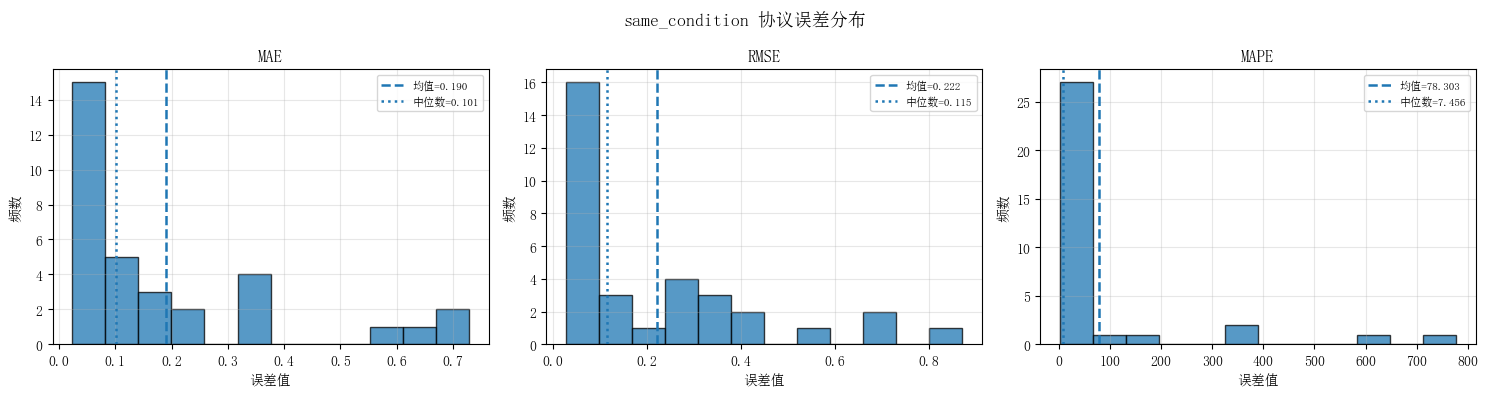

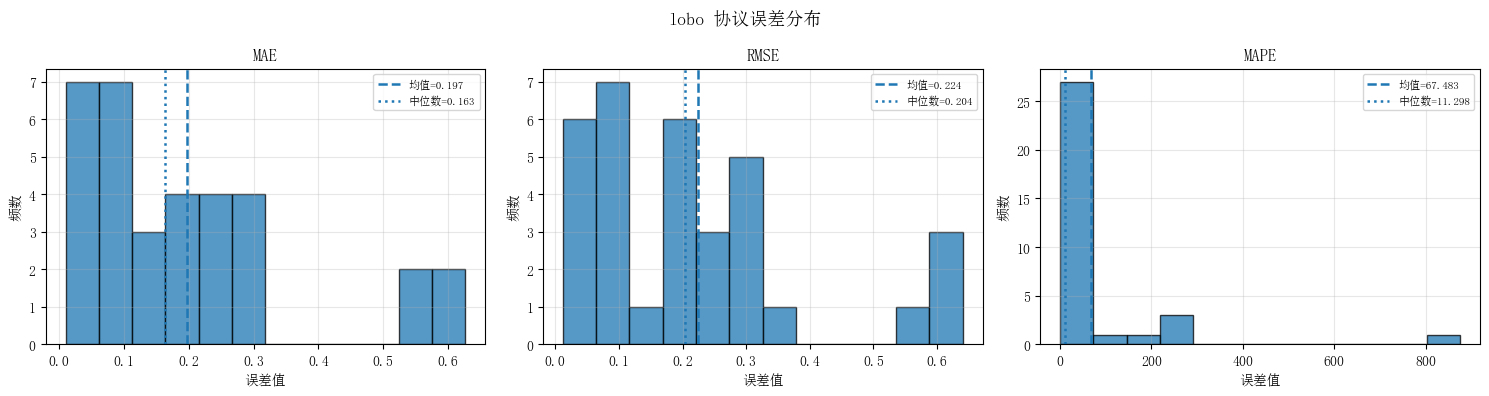

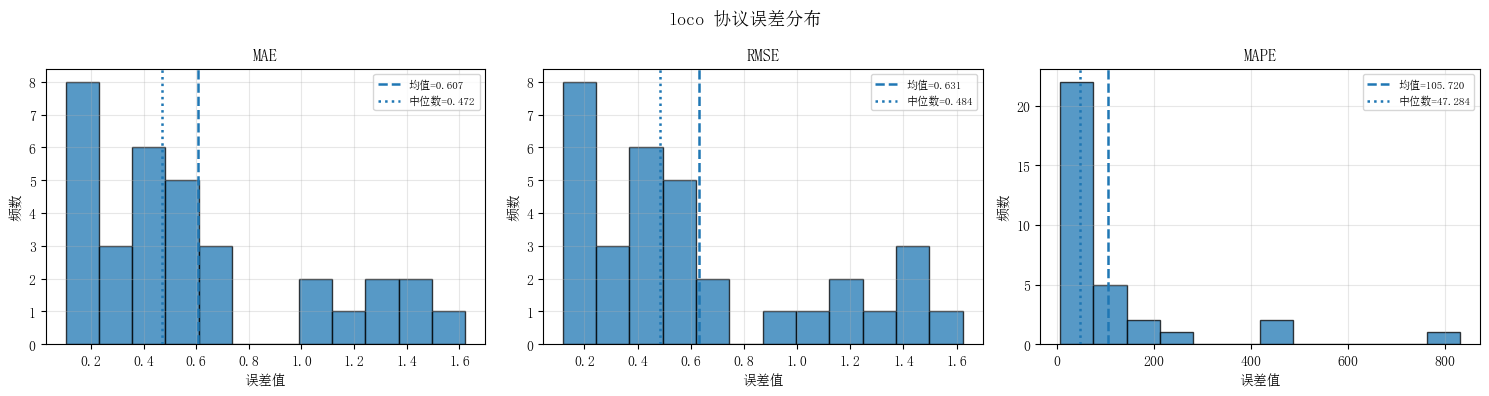

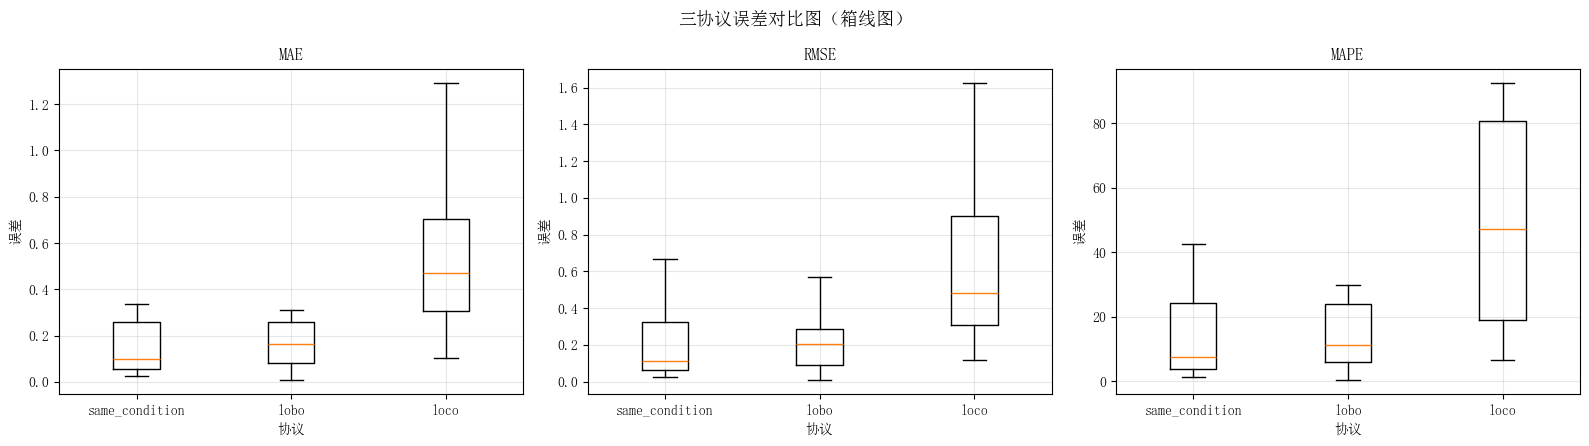


统一图表绘制完成：
1) 每个协议各1张误差分布图（含 MAE/RMSE/MAPE）
2) 1张三协议对比图（MAE/RMSE/MAPE 箱线图）


In [14]:
# 统一图表：每个协议1张误差分布图 + 1张三协议对比图
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

if 'df_lstm_all_protocols' not in globals() or df_lstm_all_protocols.empty:
    print('df_lstm_all_protocols 为空，请先运行三协议主单元。')
else:
    # ---------- 中文字体兼容（优先宋体） ----------
    def _setup_cn_font():
        candidates = [
            'SimSun', 'Songti SC', 'NSimSun', 'Microsoft YaHei',
            'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS', 'DejaVu Sans'
        ]
        available = {f.name for f in font_manager.fontManager.ttflist}
        selected = next((name for name in candidates if name in available), 'DejaVu Sans')
        mpl.rcParams['font.family'] = selected
        mpl.rcParams['axes.unicode_minus'] = False
        return selected

    selected_font = _setup_cn_font()
    print(f'当前绘图字体: {selected_font}')

    df_show = df_lstm_all_protocols.copy()
    metrics = ['MAE', 'RMSE', 'MAPE']
    protocol_order = ['same_condition', 'lobo', 'loco']

    # ---------- 图1-图3：每个协议各1张误差分布图（含MAE/RMSE/MAPE） ----------
    for protocol_name in protocol_order:
        part = df_show[df_show['protocol'] == protocol_name].copy()
        if part.empty:
            print(f'[{protocol_name}] 无数据，跳过。')
            continue

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'{protocol_name} 协议误差分布', fontsize=13)

        for ax, metric in zip(axes, metrics):
            values = part[metric].dropna().values
            if len(values) == 0:
                ax.set_title(f'{metric}（无数据）')
                ax.axis('off')
                continue

            # 直方图 + 均值/中位数标记
            ax.hist(values, bins=12, alpha=0.75, edgecolor='black')
            mean_v = float(np.mean(values))
            med_v = float(np.median(values))
            ax.axvline(mean_v, linestyle='--', linewidth=1.8, label=f'均值={mean_v:.3f}')
            ax.axvline(med_v, linestyle=':', linewidth=1.8, label=f'中位数={med_v:.3f}')
            ax.set_title(metric)
            ax.set_xlabel('误差值')
            ax.set_ylabel('频数')
            ax.grid(alpha=0.3)
            ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()

    # ---------- 图4：三协议对比图（MAE/RMSE/MAPE） ----------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle('三协议误差对比图（箱线图）', fontsize=13)

    for ax, metric in zip(axes, metrics):
        data = [df_show.loc[df_show['protocol'] == p, metric].dropna().values for p in protocol_order]
        ax.boxplot(data, tick_labels=protocol_order, showfliers=False)
        ax.set_title(metric)
        ax.set_xlabel('协议')
        ax.set_ylabel('误差')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('\n统一图表绘制完成：')
    print('1) 每个协议各1张误差分布图（含 MAE/RMSE/MAPE）')
    print('2) 1张三协议对比图（MAE/RMSE/MAPE 箱线图）')